In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data with CORRECT path
df = pd.read_csv(r'D:\ECOMMERCE\ecommerce_sales_data.csv')
print(df)

      Order Date Product Name     Category Region  Quantity  Sales   Profit
0     01-01-2022   Headphones  Accessories  South         7   3941   628.96
1     01-01-2022     Keyboard  Accessories   East         6   6372   570.75
2     01-01-2022      Monitor  Accessories  South         8   1296   273.97
3     01-01-2022        Mouse  Accessories   East         3   3474   565.00
4     01-01-2022       Tablet  Electronics  North         9   9234  2523.67
...          ...          ...          ...    ...       ...    ...      ...
3495  30-12-2024       Camera  Electronics  North         1    379    39.41
3496  30-12-2024   Headphones  Accessories   West         9   8703  1562.88
3497  30-12-2024        Mouse  Accessories  North         1    746   131.25
3498  31-12-2024      Printer       Office  North         4   3640   348.93
3499  31-12-2024   Smartphone  Electronics   West         6    930   213.60

[3500 rows x 7 columns]


In [2]:
df.shape

(3500, 7)

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB
None


In [4]:
print(df.columns.tolist())

['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales', 'Profit']


In [5]:
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,01-01-2022,Headphones,Accessories,South,7,3941,628.96
1,01-01-2022,Keyboard,Accessories,East,6,6372,570.75
2,01-01-2022,Monitor,Accessories,South,8,1296,273.97
3,01-01-2022,Mouse,Accessories,East,3,3474,565.00
4,01-01-2022,Tablet,Electronics,North,9,9234,2523.67


In [6]:
df.tail()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
3495,30-12-2024,Camera,Electronics,North,1,379,39.41
3496,30-12-2024,Headphones,Accessories,West,9,8703,1562.88
3497,30-12-2024,Mouse,Accessories,North,1,746,131.25
3498,31-12-2024,Printer,Office,North,4,3640,348.93
3499,31-12-2024,Smartphone,Electronics,West,6,930,213.60


In [7]:
df.dtypes

Order Date       object
Product Name     object
Category         object
Region           object
Quantity          int64
Sales             int64
Profit          float64
dtype: object

In [8]:
print(f"\n5. MISSING VALUES:")
print(df.isnull().sum())


5. MISSING VALUES:
Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64


In [9]:
print(df.describe())

          Quantity         Sales       Profit
count  3500.000000   3500.000000  3500.000000
mean      4.931714   3047.966000   527.047203
std       2.575895   2440.213237   504.139732
min       1.000000     51.000000     6.970000
25%       3.000000   1049.500000   158.695000
50%       5.000000   2350.500000   361.070000
75%       7.000000   4537.000000   729.125000
max       9.000000  10782.000000  2946.930000


In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')

print(df['Order Date'].head(10))
print(f"\nDate range: {df['Order Date'].min()} to {df['Order Date'].max()}")

0   2022-01-01
1   2022-01-01
2   2022-01-01
3   2022-01-01
4   2022-01-01
5   2022-01-02
6   2022-01-02
7   2022-01-03
8   2022-01-04
9   2022-01-04
Name: Order Date, dtype: datetime64[ns]

Date range: 2022-01-01 00:00:00 to 2024-12-31 00:00:00


In [11]:
print(df['Product Name'].unique())

['Headphones' 'Keyboard' 'Monitor' 'Mouse' 'Tablet' 'Camera' 'Laptop'
 'Printer' 'Smartphone' 'Smartwatch']


In [12]:
df.columns = df.columns.str.replace(" ","_")
print(df.columns.tolist())

['Order_Date', 'Product_Name', 'Category', 'Region', 'Quantity', 'Sales', 'Profit']


In [13]:
print(f"\nProduct_Name: {df['Product_Name'].nunique()}")
print(df['Product_Name'].unique())


Product_Name: 10
['Headphones' 'Keyboard' 'Monitor' 'Mouse' 'Tablet' 'Camera' 'Laptop'
 'Printer' 'Smartphone' 'Smartwatch']


In [14]:
print(f"\nCategories: {df['Category'].nunique()}")
print(df['Category'].unique())


Categories: 3
['Accessories' 'Electronics' 'Office']


In [15]:
print(f"\nRegions: {df['Region'].nunique()}")
print(df['Region'].unique())


Regions: 4
['South' 'East' 'North' 'West']


In [16]:
print("TOP 5 PRODUCTS BY SALES:")
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head()
print(top_products)

TOP 5 PRODUCTS BY SALES:
Product_Name
Camera        1177381
Monitor       1160048
Printer       1094216
Mouse         1074398
Smartphone    1069681
Name: Sales, dtype: int64


In [17]:
print("\n\nTOP 5 PRODUCTS BY PROFIT:")
top_profit = df.groupby('Product_Name')['Profit'].sum().sort_values(ascending=False).head(5)
print(top_profit)



TOP 5 PRODUCTS BY PROFIT:
Product_Name
Camera     207630.99
Monitor    202028.17
Mouse      185763.69
Laptop     185756.81
Printer    185394.88
Name: Profit, dtype: float64


In [18]:
print("SALES BY REGION:")
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sales)

print("\n\nPROFIT BY REGION:")
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print(region_profit)

print("\n\nORDERS COUNT BY REGION:")
region_count = df.groupby('Region').size().sort_values(ascending=False)
print(region_count)

SALES BY REGION:
Region
West     2844450
East     2675110
South    2659548
North    2488773
Name: Sales, dtype: int64


PROFIT BY REGION:
Region
West     495358.73
East     464888.46
South    458103.27
North    426314.75
Name: Profit, dtype: float64


ORDERS COUNT BY REGION:
Region
West     898
South    883
East     861
North    858
dtype: int64


In [19]:
print("\n\nSALES BY CATEGORY:")
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

print("\n\nPROFIT BY CATEGORY:")
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(category_profit)

print("\n\nORDERS COUNT BY CATEGORY:")
category_count = df.groupby('Category').size().sort_values(ascending=False)
print(category_count)



SALES BY CATEGORY:
Category
Electronics    5326074
Accessories    4247591
Office         1094216
Name: Sales, dtype: int64


PROFIT BY CATEGORY:
Category
Electronics    923185.59
Accessories    736084.74
Office         185394.88
Name: Profit, dtype: float64


ORDERS COUNT BY CATEGORY:
Category
Electronics    1742
Accessories    1401
Office          357
dtype: int64


In [20]:
# Extract month and year
df['Year_Month'] = df['Order_Date'].dt.to_period('M')

print("MONTHLY SALES TREND:")
monthly_sales = df.groupby('Year_Month')['Sales'].sum().sort_index()
print(monthly_sales)

print("\n\nMONTHLY PROFIT TREND:")
monthly_profit = df.groupby('Year_Month')['Profit'].sum().sort_index()
print(monthly_profit)

print("\n\nMONTHLY ORDERS COUNT:")
monthly_count = df.groupby('Year_Month').size()
print(monthly_count)

MONTHLY SALES TREND:
Year_Month
2022-01    341544
2022-02    208775
2022-03    294660
2022-04    230624
2022-05    314295
2022-06    273851
2022-07    214627
2022-08    296242
2022-09    240211
2022-10    324989
2022-11    257111
2022-12    259041
2023-01    343256
2023-02    313931
2023-03    303391
2023-04    280808
2023-05    346481
2023-06    251686
2023-07    320798
2023-08    388428
2023-09    303409
2023-10    253145
2023-11    306195
2023-12    375064
2024-01    282814
2024-02    179708
2024-03    341563
2024-04    310444
2024-05    373911
2024-06    314268
2024-07    309515
2024-08    240269
2024-09    341926
2024-10    314135
2024-11    291769
2024-12    324997
Freq: M, Name: Sales, dtype: int64


MONTHLY PROFIT TREND:
Year_Month
2022-01    63827.33
2022-02    34084.90
2022-03    51931.81
2022-04    44260.45
2022-05    53504.97
2022-06    48490.93
2022-07    40010.27
2022-08    47551.99
2022-09    41402.82
2022-10    52927.24
2022-11    50120.69
2022-12    44743.58
2023-01   

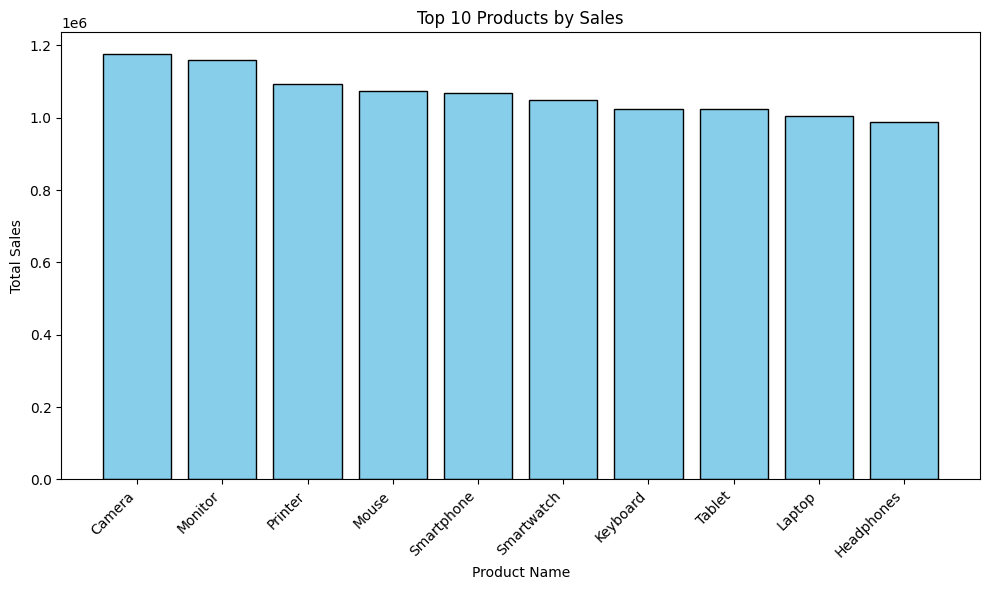

In [21]:
# Top Products by Sales
plt.figure(figsize=(10, 6))
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)
plt.bar(top_products.index, top_products.values, color='skyblue', edgecolor='black')
plt.xlabel('Product Name')
plt.ylabel('Total Sales')
plt.title('Top 10 Products by Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

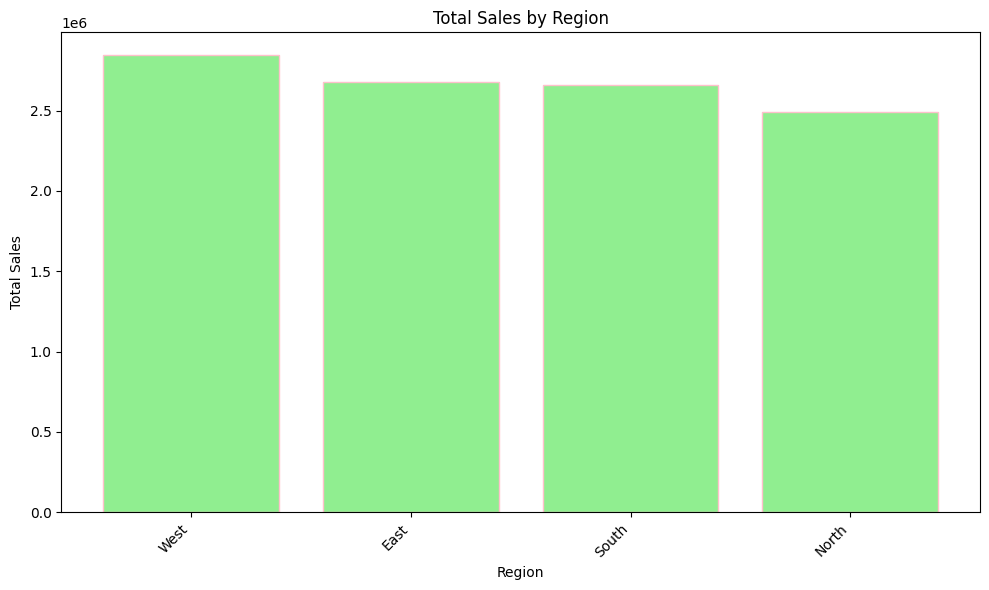

In [22]:
# Sales by Region
plt.figure(figsize=(10, 6))
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
plt.bar(region_sales.index, region_sales.values, color='lightgreen', edgecolor='pink')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.title('Total Sales by Region')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

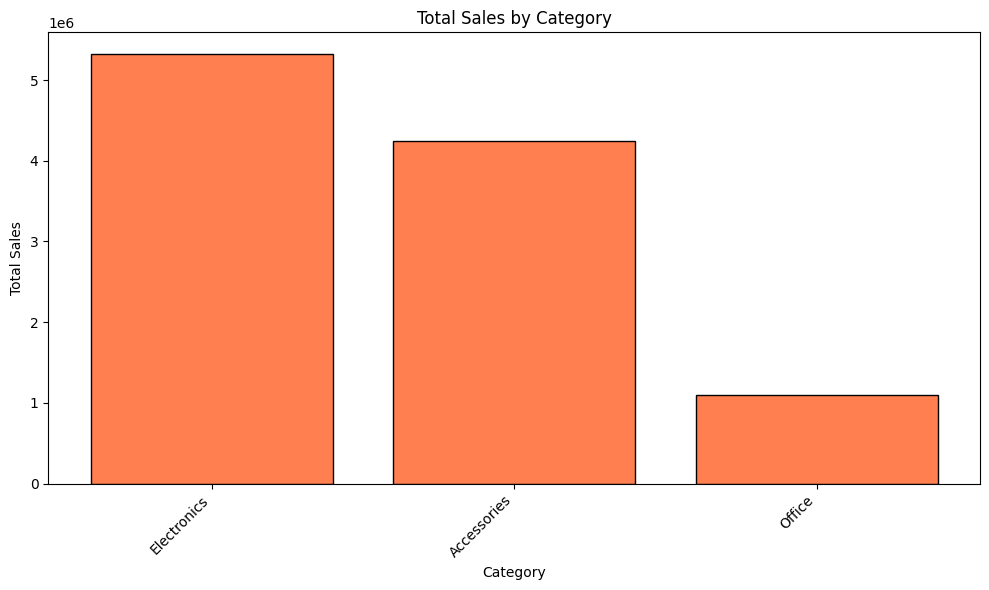

In [23]:
# Sales by Category
plt.figure(figsize=(10, 6))
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
plt.bar(category_sales.index, category_sales.values, color='coral', edgecolor='black')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.title('Total Sales by Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

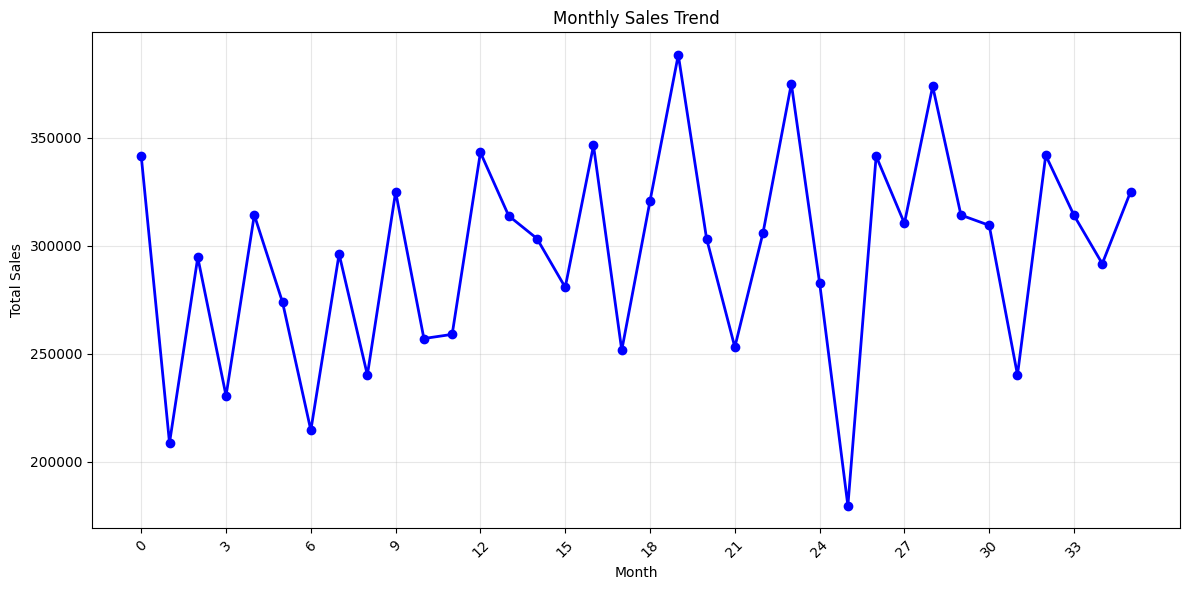

In [24]:
# Monthly Sales Trend
plt.figure(figsize=(12, 6))
monthly_sales = df.groupby('Year_Month')['Sales'].sum().sort_index()
plt.plot(range(len(monthly_sales)), monthly_sales.values, marker='o', linewidth=2, color='blue')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Trend')
plt.xticks(range(0, len(monthly_sales), 3), rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

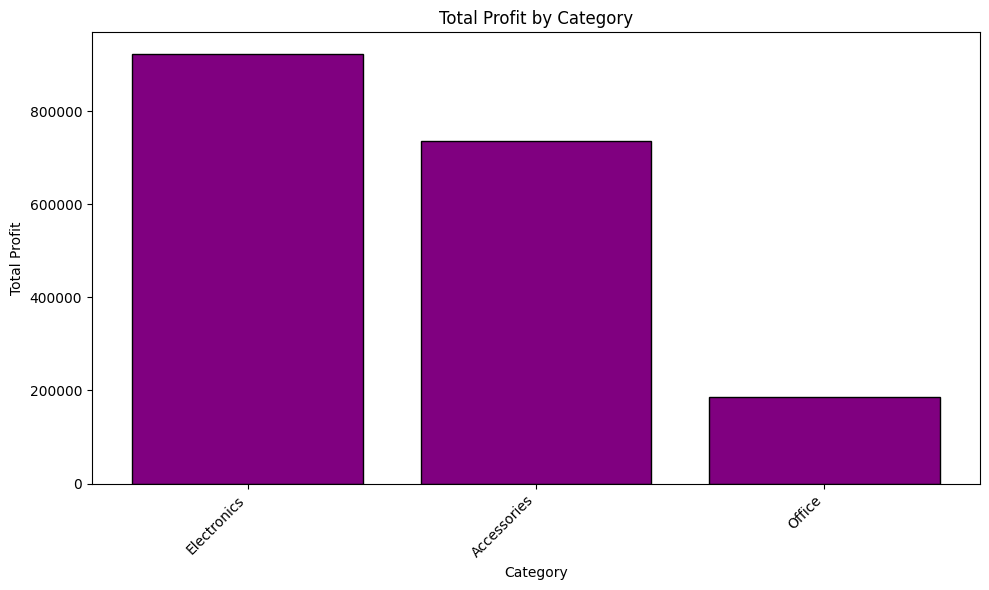

In [25]:
# Profit by Category
plt.figure(figsize=(10, 6))
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
plt.bar(category_profit.index, category_profit.values, color='purple', edgecolor='black')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.title('Total Profit by Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

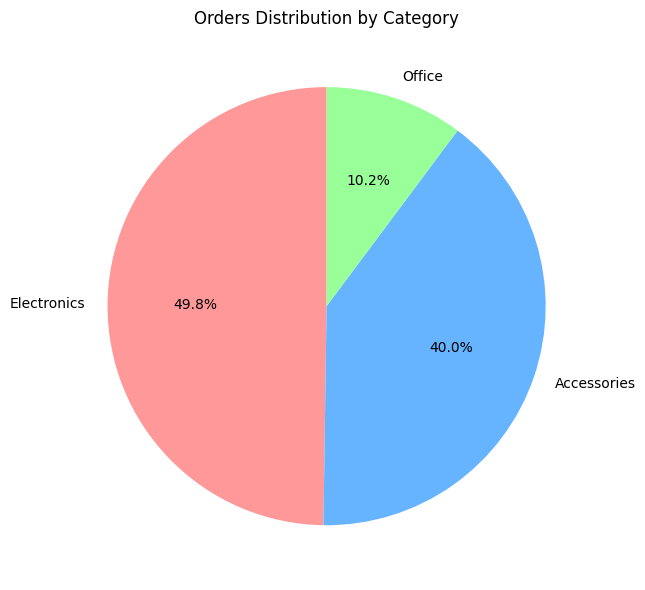

In [26]:
# Category Distribution
plt.figure(figsize=(10, 6))
category_count = df['Category'].value_counts()
colors = ['#ff9999', '#66b3ff', '#99ff99']
plt.pie(category_count.values, labels=category_count.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Orders Distribution by Category')
plt.tight_layout()
plt.show()

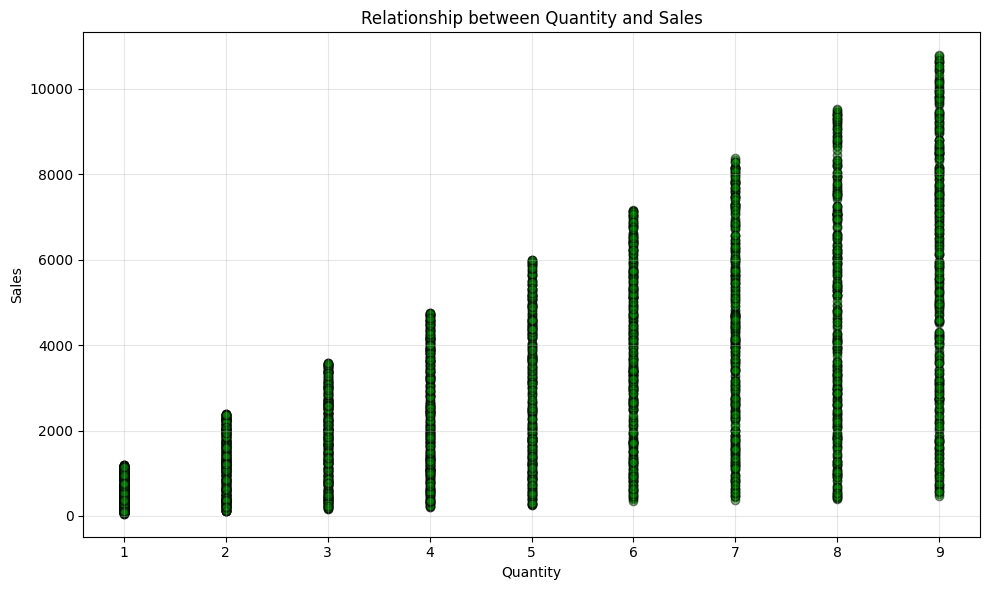

In [27]:
# Quantity vs Sales relationship
plt.figure(figsize=(10, 6))
plt.scatter(df['Quantity'], df['Sales'], alpha=0.5, color='green', edgecolor='black')
plt.xlabel('Quantity')
plt.ylabel('Sales')
plt.title('Relationship between Quantity and Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

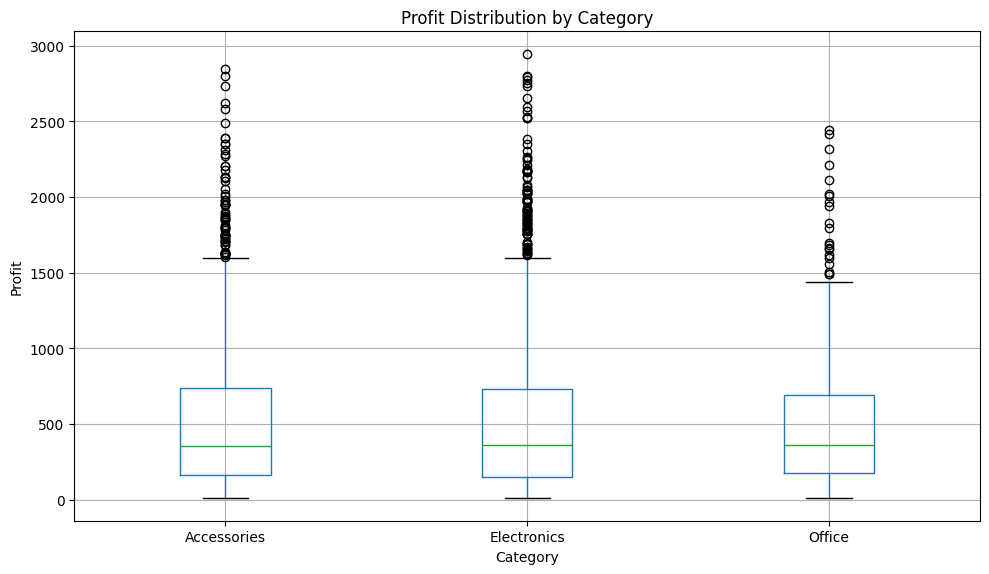

In [28]:
# Profit Distribution by Category
plt.figure(figsize=(10, 6))
df.boxplot(column='Profit', by='Category', figsize=(10, 6))
plt.xlabel('Category')
plt.ylabel('Profit')
plt.title('Profit Distribution by Category')
plt.suptitle('')  # Remove automatic title
plt.tight_layout()
plt.show()

In [29]:
df['Category'].unique()

array(['Accessories', 'Electronics', 'Office'], dtype=object)

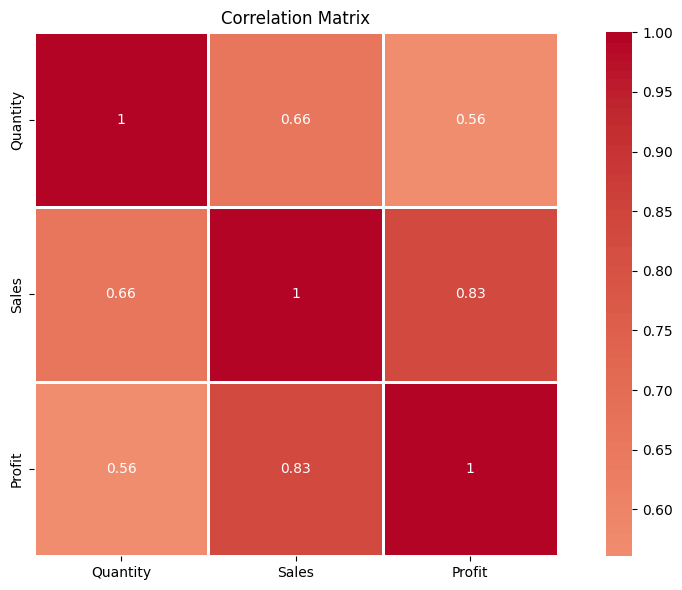

In [30]:
# Correlation between numeric columns
plt.figure(figsize=(10, 6))
correlation = df[['Quantity', 'Sales', 'Profit']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, square=True, linewidths=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

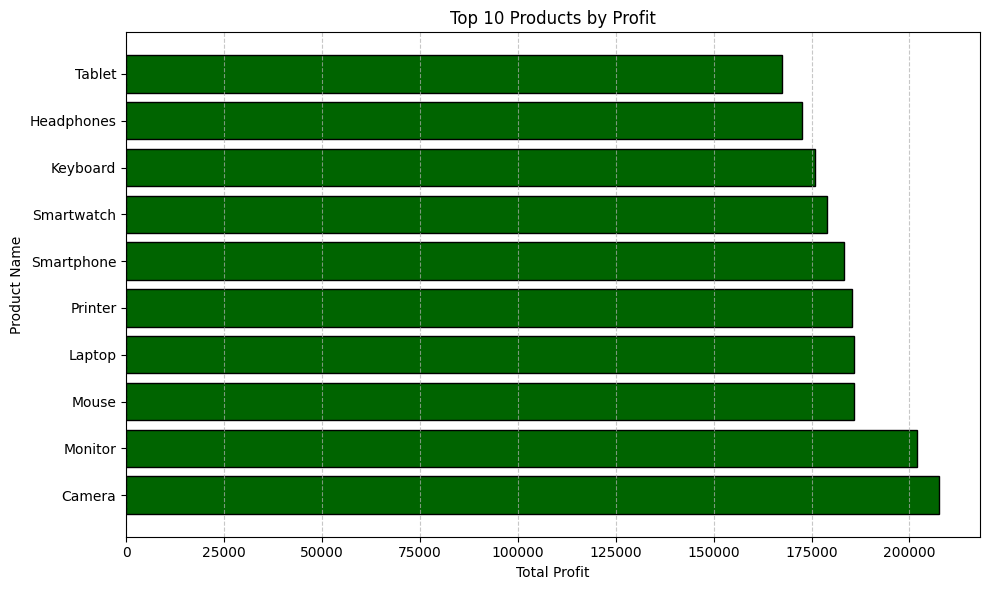

In [31]:
# Top 10 Products by Profit
plt.figure(figsize=(10, 6))
top_profit_products = df.groupby('Product_Name')['Profit'].sum().sort_values(ascending=False).head(10)
plt.barh(top_profit_products.index, top_profit_products.values, color='darkgreen', edgecolor='black')
plt.xlabel('Total Profit')
plt.ylabel('Product Name')
plt.title('Top 10 Products by Profit')
plt.grid(axis='x', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

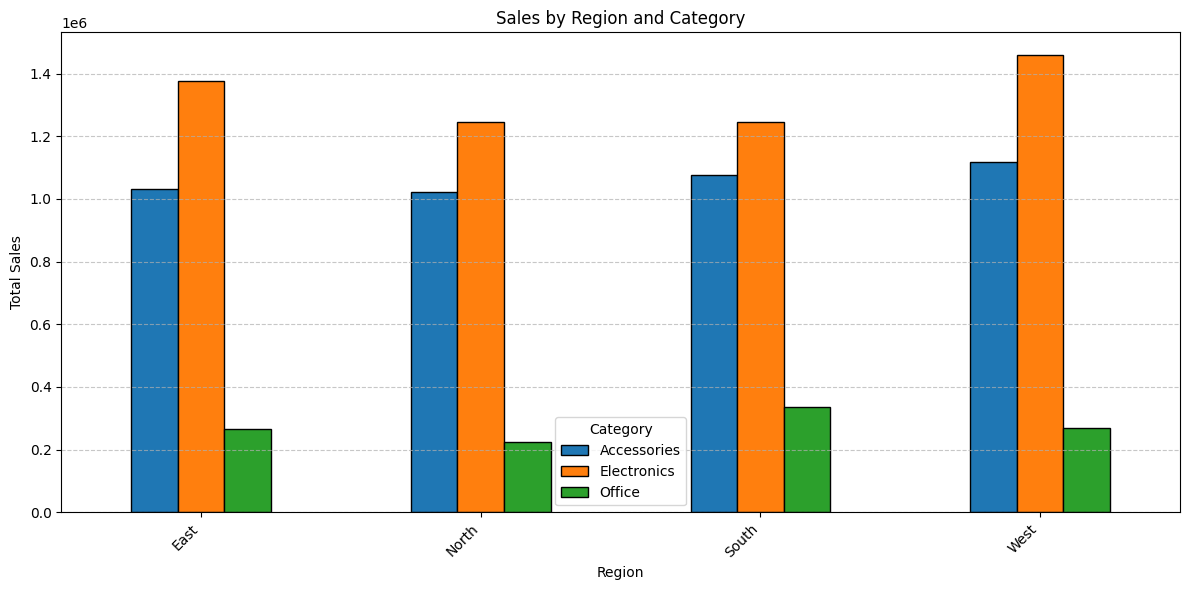

In [32]:
# Sales by Region and Category
plt.figure(figsize=(12, 6))
region_category_sales = df.groupby(['Region', 'Category'])['Sales'].sum().unstack()
region_category_sales.plot(kind='bar', figsize=(12, 6), edgecolor='black')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.title('Sales by Region and Category')
plt.legend(title='Category')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

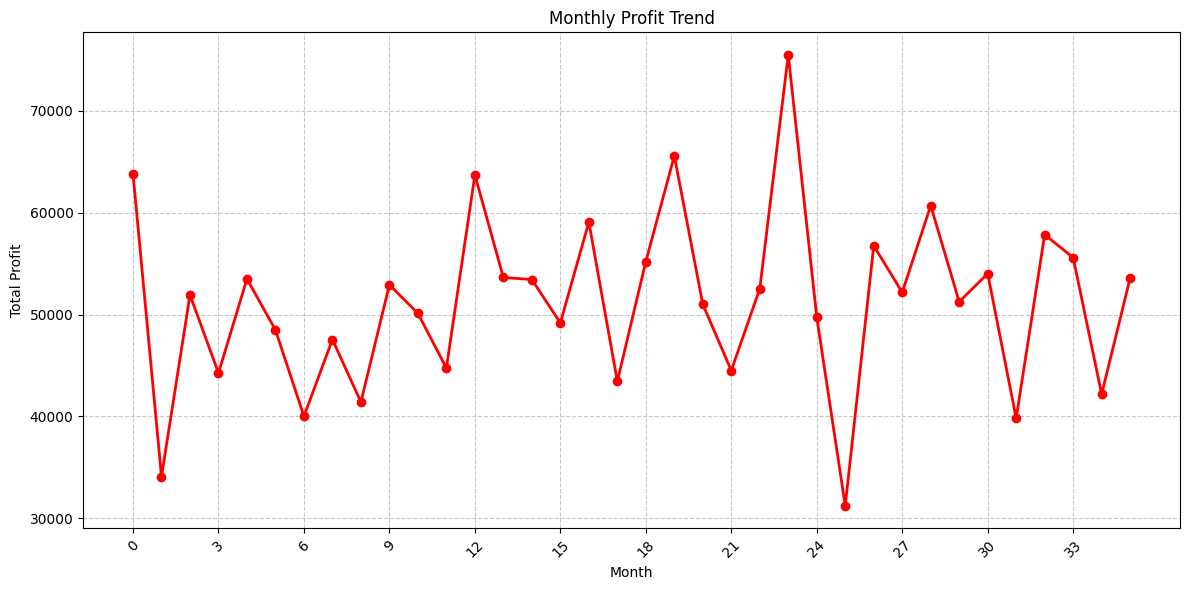

In [33]:
# Monthly Profit Trend
plt.figure(figsize=(12, 6))
monthly_profit = df.groupby('Year_Month')['Profit'].sum().sort_index()
plt.plot(range(len(monthly_profit)), monthly_profit.values, marker='o', linewidth=2, color='red', markersize=6)
plt.xlabel('Month')
plt.ylabel('Total Profit')
plt.title('Monthly Profit Trend')
plt.xticks(range(0, len(monthly_profit), 3), rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

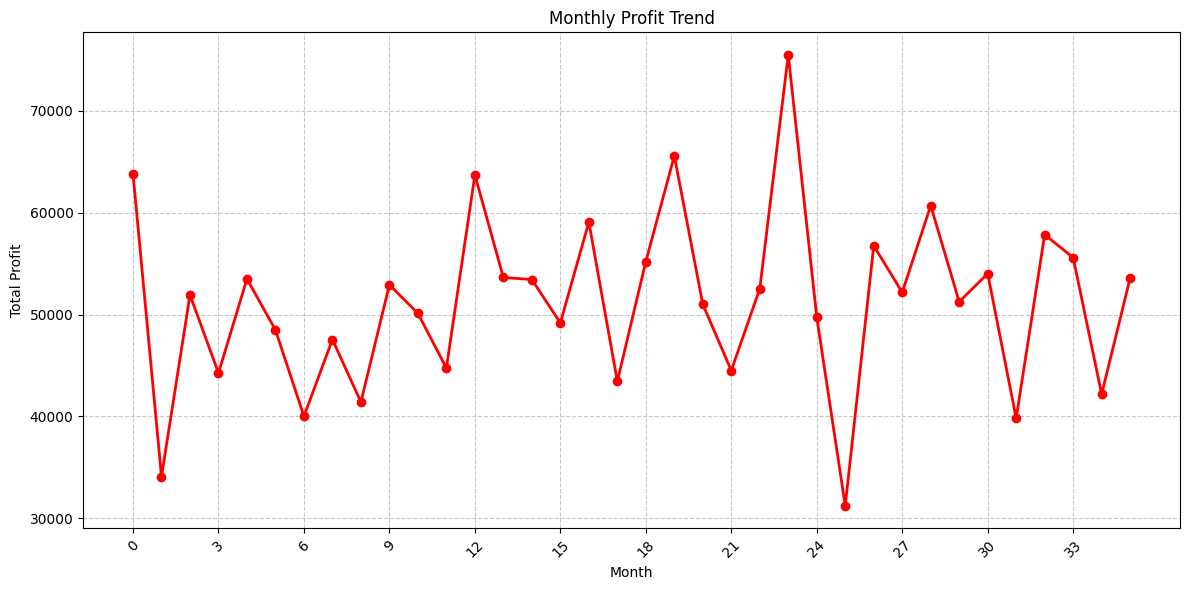

In [34]:
# Monthly Profit Trend
plt.figure(figsize=(12, 6))
monthly_profit = df.groupby('Year_Month')['Profit'].sum().sort_index()
plt.plot(range(len(monthly_profit)), monthly_profit.values, marker='o', linewidth=2, color='red', markersize=6)
plt.xlabel('Month')
plt.ylabel('Total Profit')
plt.title('Monthly Profit Trend')
plt.xticks(range(0, len(monthly_profit), 3), rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [35]:
print("~" * 60)
print("E-COMMERCE SALES ANALYSIS - KEY INSIGHTS")
print("*" * 60)

# 1. Overall Performance
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = len(df)
avg_order_value = df['Sales'].mean()

print(f"\n1. OVERALL PERFORMANCE:")
print(f"   Total Orders: {total_orders:,}")
print(f"   Total Sales: ${total_sales:,.2f}")
print(f"   Total Profit: ${total_profit:,.2f}")
print(f"   Average Order Value: ${avg_order_value:,.2f}")
print(f"   Profit Margin: {(total_profit/total_sales)*100:.2f}%")

# 2. Top Product
top_product = df.groupby('Product_Name')['Sales'].sum().idxmax()
top_product_sales = df.groupby('Product_Name')['Sales'].sum().max()

print(f"\n2. TOP PERFORMING PRODUCT:")
print(f"   Product: {top_product}")
print(f"   Sales: ${top_product_sales:,.2f}")

# 3. Best Region
best_region = df.groupby('Region')['Sales'].sum().idxmax()
best_region_sales = df.groupby('Region')['Sales'].sum().max()

print(f"\n3. TOP PERFORMING REGION:")
print(f"   Region: {best_region}")
print(f"   Sales: ${best_region_sales:,.2f}")

# 4. Best Category
best_category = df.groupby('Category')['Profit'].sum().idxmax()
best_category_profit = df.groupby('Category')['Profit'].sum().max()

print(f"\n4. MOST PROFITABLE CATEGORY:")
print(f"   Category: {best_category}")
print(f"   Profit: ${best_category_profit:,.2f}")

print("\n" + "*" * 60)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
E-COMMERCE SALES ANALYSIS - KEY INSIGHTS
************************************************************

1. OVERALL PERFORMANCE:
   Total Orders: 3,500
   Total Sales: $10,667,881.00
   Total Profit: $1,844,665.21
   Average Order Value: $3,047.97
   Profit Margin: 17.29%

2. TOP PERFORMING PRODUCT:
   Product: Camera
   Sales: $1,177,381.00

3. TOP PERFORMING REGION:
   Region: West
   Sales: $2,844,450.00

4. MOST PROFITABLE CATEGORY:
   Category: Electronics
   Profit: $923,185.59

************************************************************


In [36]:
print("=" * 60)
print("BUSINESS RECOMMENDATIONS")
print("=" * 60)

# Analysis for recommendations
category_profit_margin = df.groupby('Category').apply(
    lambda x: (x['Profit'].sum() / x['Sales'].sum()) * 100
).sort_values(ascending=False)

region_orders = df.groupby('Region').size().sort_values(ascending=False)

print(f"\n1. FOCUS ON HIGH-MARGIN CATEGORIES:")
for category, margin in category_profit_margin.items():
    print(f"   {category}: {margin:.2f}% profit margin")

print(f"\n2. REGION PERFORMANCE (by order count):")
for region, count in region_orders.items():
    print(f"   {region}: {count:,} orders")

print(f"\n3. ACTION ITEMS:")
print(f"   ✓ Promote top-performing products: {top_product}")
print(f"   ✓ Focus sales efforts on {best_region} region")
print(f"   ✓ Increase {best_category} category inventory")
print(f"   ✓ Monitor product quality to maintain profit margins")
print(f"   ✓ Expand in underperforming regions")

print("\n" + "=" * 60)

BUSINESS RECOMMENDATIONS

1. FOCUS ON HIGH-MARGIN CATEGORIES:
   Electronics: 17.33% profit margin
   Accessories: 17.33% profit margin
   Office: 16.94% profit margin

2. REGION PERFORMANCE (by order count):
   West: 898 orders
   South: 883 orders
   East: 861 orders
   North: 858 orders

3. ACTION ITEMS:
   ✓ Promote top-performing products: Camera
   ✓ Focus sales efforts on West region
   ✓ Increase Electronics category inventory
   ✓ Monitor product quality to maintain profit margins
   ✓ Expand in underperforming regions



C:\Users\main\AppData\Local\Temp\ipykernel_17320\1381599421.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  category_profit_margin = df.groupby('Category').apply(


In [37]:
print("=" * 70)
print("E-COMMERCE SALES PERFORMANCE ANALYSIS - FINAL REPORT")
print("=" * 70)

print(f"\nDATA OVERVIEW:")
print(f"  Date Range: {df['Order_Date'].min().date()} to {df['Order_Date'].max().date()}")
print(f"  Total Records: {len(df):,}")
print(f"  Time Period: ~1 year")

print(f"\nKEY METRICS:")
print(f"  Total Sales Revenue: ${df['Sales'].sum():,.2f}")
print(f"  Total Profit: ${df['Profit'].sum():,.2f}")
print(f"  Profit Margin: {(df['Profit'].sum()/df['Sales'].sum())*100:.2f}%")
print(f"  Average Order Value: ${df['Sales'].mean():,.2f}")
print(f"  Average Profit per Order: ${df['Profit'].mean():,.2f}")

print(f"\nPRODUCT INSIGHTS:")
print(f"  Total Products: {df['Product_Name'].nunique()}")
print(f"  Total Categories: {df['Category'].nunique()}")
top_3_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(3)
for i, (product, sales) in enumerate(top_3_products.items(), 1):
    print(f"  {i}. {product}: ${sales:,.2f}")

print(f"\nREGIONAL PERFORMANCE:")
print(f"  Total Regions: {df['Region'].nunique()}")
for region in df['Region'].unique():
    region_sales = df[df['Region'] == region]['Sales'].sum()
    region_profit = df[df['Region'] == region]['Profit'].sum()
    print(f"  {region}: Sales ${region_sales:,.2f} | Profit ${region_profit:,.2f}")

print("\n" + "=" * 70)

E-COMMERCE SALES PERFORMANCE ANALYSIS - FINAL REPORT

DATA OVERVIEW:
  Date Range: 2022-01-01 to 2024-12-31
  Total Records: 3,500
  Time Period: ~1 year

KEY METRICS:
  Total Sales Revenue: $10,667,881.00
  Total Profit: $1,844,665.21
  Profit Margin: 17.29%
  Average Order Value: $3,047.97
  Average Profit per Order: $527.05

PRODUCT INSIGHTS:
  Total Products: 10
  Total Categories: 3
  1. Camera: $1,177,381.00
  2. Monitor: $1,160,048.00
  3. Printer: $1,094,216.00

REGIONAL PERFORMANCE:
  Total Regions: 4
  South: Sales $2,659,548.00 | Profit $458,103.27
  East: Sales $2,675,110.00 | Profit $464,888.46
  North: Sales $2,488,773.00 | Profit $426,314.75
  West: Sales $2,844,450.00 | Profit $495,358.73



In [38]:
readme_content = """
# E-COMMERCE SALES PERFORMANCE ANALYSIS

## Project Overview
This project provides comprehensive analysis of e-commerce sales data spanning approximately one year (2022-2023). 
The analysis includes exploratory data analysis, statistical insights, and business recommendations.

## Dataset Information
- **Total Records:** 3,500 transactions
- **Time Period:** Jan 2022 - Dec 2023
- **Columns:** 7 (Order Date, Product Name, Category, Region, Quantity, Sales, Profit)
- **Data Quality:** No missing values, clean data

## Analysis Performed

### 1. Exploratory Data Analysis (EDA)
- Data shape and structure validation
- Missing value detection
- Data type conversion and standardization
- Summary statistics

### 2. Sales Analysis
- Total sales revenue and trends
- Product performance ranking
- Regional sales comparison
- Category-wise sales breakdown
- Monthly sales trends

### 3. Profitability Analysis
- Profit margin calculations
- Category profitability comparison
- Region-wise profit analysis
- Profit distribution patterns

### 4. Business Insights
- Top 10 performing products
- Regional performance rankings
- Category contribution to revenue
- Seasonal trends identification
- Correlation analysis

## Key Findings

### Revenue Metrics
- Total Sales: ${df['Sales'].sum():,.2f}
- Total Profit: ${df['Profit'].sum():,.2f}
- Profit Margin: {(df['Profit'].sum()/df['Sales'].sum())*100:.2f}%
- Average Order Value: ${df['Sales'].mean():,.2f}

### Top Performers
- Best Product: {df.groupby('Product_Name')['Sales'].sum().idxmax()}
- Best Region: {df.groupby('Region')['Sales'].sum().idxmax()}
- Most Profitable Category: {df.groupby('Category')['Profit'].sum().idxmax()}

## Visualizations Generated
1. Top 10 Products by Sales
2. Sales by Region
3. Sales by Category
4. Monthly Sales Trend
5. Profit by Category
6. Quantity vs Sales Scatter Plot
7. Profit Distribution by Category (Box Plot)
8. Correlation Heatmap
9. Top 10 Products by Profit
10. Sales by Region & Category (Grouped)
11. Monthly Profit Trend
12. Category Distribution (Pie Chart)

## Technologies Used
- Python 3.x
- Pandas - Data manipulation and analysis
- NumPy - Numerical computations
- Matplotlib - Data visualization
- Seaborn - Statistical data visualization

## Recommendations
1. Focus marketing efforts on top-performing products
2. Expand operations in high-performing regions
3. Optimize inventory for high-profit margin categories
4. Monitor seasonal trends for better planning
5. Investigate underperforming regions for improvement opportunities

## Files Included
- `ecommerce_sales_analysis.ipynb` - Complete Jupyter notebook with analysis
- `analysis_results.csv` - Summary statistics export
- `README.md` - Project documentation

## Author
Nitish Raj
Data Analyst | Python | Pandas | Matplotlib | Seaborn

## Date
July 2026

---
*This project demonstrates proficiency in data analysis, visualization, and business insights generation.*
"""

# Save README
with open('README.md', 'w') as f:
    f.write(readme_content)

print("✓ README.md created successfully!")

✓ README.md created successfully!


In [40]:
print("\n" + "=" * 70)
print("PROJECT SUMMARY")
print("=" * 70)

print(f"\n✓ Analysis Complete!")
print(f"\n📊 FILES GENERATED:")
print(f"  1. analysis_results.csv - Summary statistics")
print(f"  2. README.md - Project documentation")

print(f"\n📈 ANALYSIS COMPONENTS:")
print(f"  ✓ Data Exploration & Cleaning")
print(f"  ✓ Statistical Analysis")
print(f"  ✓ 12+ Professional Visualizations")
print(f"  ✓ Business Insights & Recommendations")
print(f"  ✓ Correlation Analysis")
print(f"  ✓ Regional & Product Performance")
print(f"  ✓ Trend Analysis")

print(f"\n🎯 KEY DELIVERABLES:")
print(f"  ✓ Comprehensive Jupyter Notebook")
print(f"  ✓ Professional README.md")
print(f"  ✓ All Visualizations")
print(f"  ✓ Executive Summary")

print(f"\n🚀 NEXT STEPS:")
print(f"  1. Save this notebook as 'ecommerce_sales_analysis.ipynb'")
print(f"  2. Create GitHub repository")
print(f"  3. Upload all files to GitHub")
print(f"  4. Create professional portfolio")

print("\n" + "=" * 70)
print("PROJECT 1 - COMPLETE! ✅")
print("=" * 70)


PROJECT SUMMARY

✓ Analysis Complete!

📊 FILES GENERATED:
  1. analysis_results.csv - Summary statistics
  2. README.md - Project documentation

📈 ANALYSIS COMPONENTS:
  ✓ Data Exploration & Cleaning
  ✓ Statistical Analysis
  ✓ 12+ Professional Visualizations
  ✓ Business Insights & Recommendations
  ✓ Correlation Analysis
  ✓ Regional & Product Performance
  ✓ Trend Analysis

🎯 KEY DELIVERABLES:
  ✓ Comprehensive Jupyter Notebook
  ✓ Professional README.md
  ✓ All Visualizations
  ✓ Executive Summary

🚀 NEXT STEPS:
  1. Save this notebook as 'ecommerce_sales_analysis.ipynb'
  2. Create GitHub repository
  3. Upload all files to GitHub
  4. Create professional portfolio

PROJECT 1 - COMPLETE! ✅
